Dataset shape: (1500, 12)
Number of failure events: 45
Failure rate: 0.03

Operating regime distribution
-----------------------------
              share
regime_label       
normal        0.552
high_load     0.321
unstable      0.127

First rows of the simulated dataset
-----------------------------------
 time  operating_regime      load     speed  pressure  temperature  maintenance_delay     wear  vibration  failure_risk  failure regime_label
    0                 0  0.000000  0.000000  0.000000     0.000000           0.000000 0.000000   0.000000      0.000000        0       normal
    1                 0  0.564339 -1.170621 -0.781308     0.070312           0.075045 0.000000  -0.008401      0.057324        0       normal
    2                 0  0.445942 -0.049440 -0.086260    -0.638912           0.145320 0.213693  -0.562948      0.057324        0       normal
    3                 0 -0.087479  0.702872 -0.037301    -0.460886           0.112302 0.012831   0.004088      0.057324     

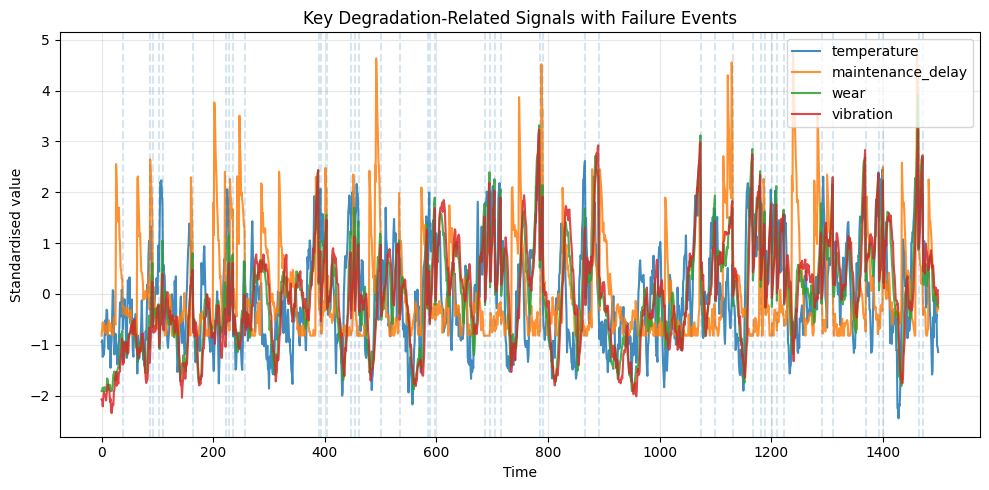

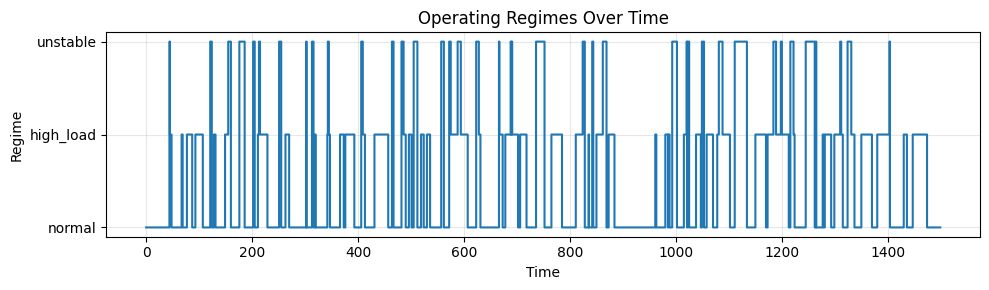


Naive correlation-based ranking
-------------------------------
                   absolute_correlation_with_failure
pressure                                    0.148095
load                                        0.141453
temperature                                 0.098732
maintenance_delay                           0.048496
wear                                        0.040408
speed                                       0.033983
vibration                                   0.031676


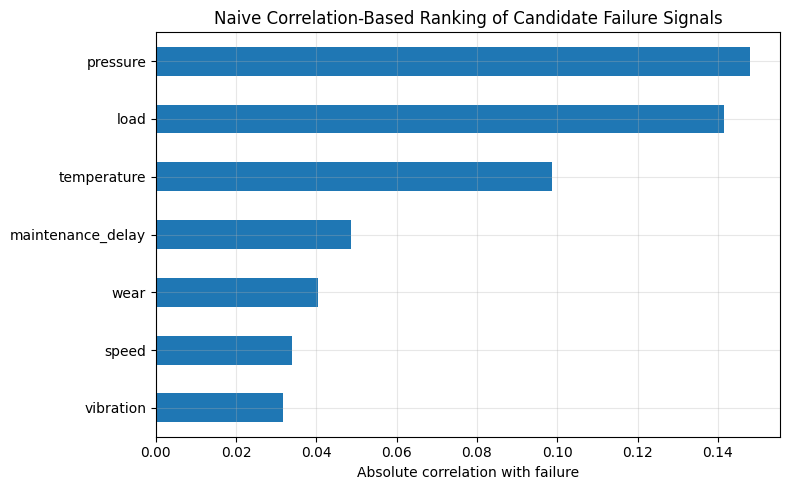


Top lag-aware dependency signals
--------------------------------
          source      target  best_lag  lagged_correlation  lagged_score
            wear   vibration         1            0.918043      0.918043
            load temperature         2            0.877800      0.877800
       vibration        wear         1            0.852012      0.852012
            load    pressure         1            0.810351      0.810351
        pressure temperature         1            0.801687      0.801687
     temperature    pressure         1            0.724545      0.724545
     temperature        wear         3            0.716512      0.716512
        pressure        load         1            0.698901      0.698901
     temperature        load         1            0.662095      0.662095
operating_regime    pressure         2            0.655860      0.655860

Top Granger-style time-ordered signals
--------------------------------------
          source      target  best_lag       p_valu

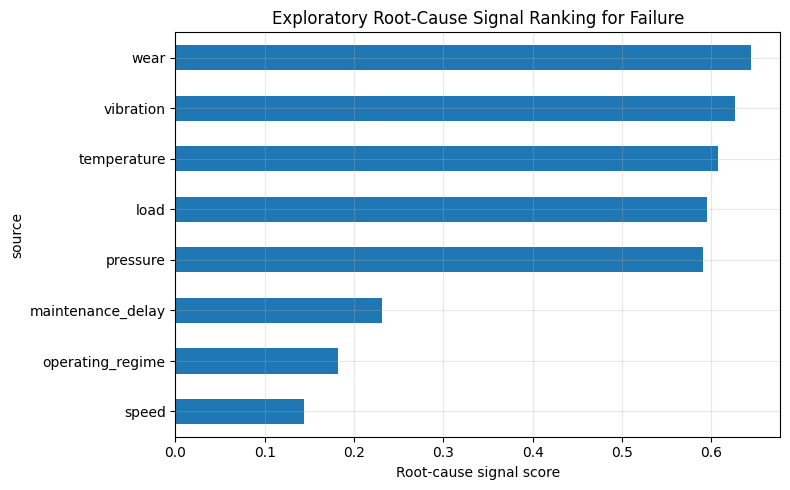


Predictive baseline: logistic regression with lagged features
--------------------------------------------------------------
Time-based train/test split: 70% train, 30% test
Test ROC AUC: 0.804

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.78      0.87       433
           1       0.10      0.62      0.17        16

    accuracy                           0.78       449
   macro avg       0.54      0.70      0.52       449
weighted avg       0.95      0.78      0.84       449


Top predictive lagged features
------------------------------
               feature  coefficient  absolute_coefficient
        vibration_lag5    -1.515749              1.515749
             wear_lag5     1.415630              1.415630
             wear_lag1     1.412859              1.412859
      temperature_lag3    -1.335195              1.335195
        vibration_lag4    -1.329679              1.329679
        vibration_lag1     1.308377        

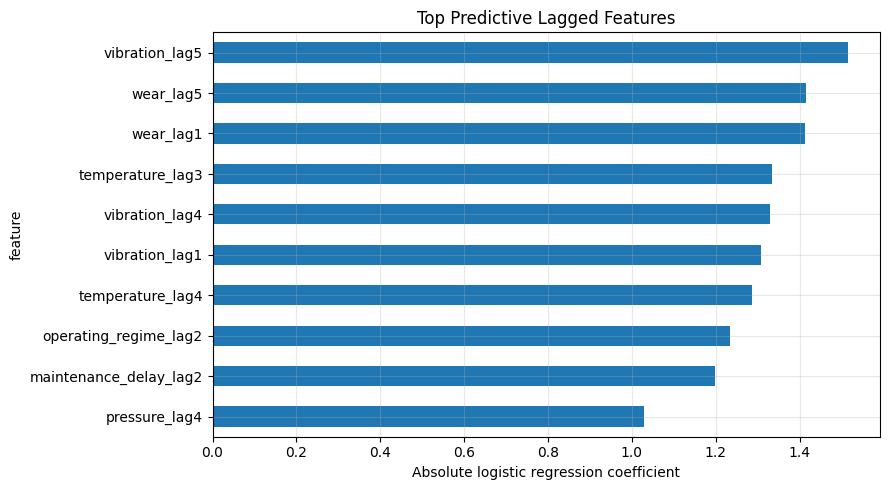


Local pre-failure explanation for failure at time 389
------------------------------------------------------------------------

Local pre-failure changes
-------------------------
         variable  baseline_mean  pre_failure_mean   change  absolute_change
      temperature       0.665890          3.603423 2.937533         2.937533
        vibration       8.284881         10.338075 2.053194         2.053194
             wear       5.891803          7.658569 1.766766         1.766766
maintenance_delay       0.259016          0.352524 0.093508         0.093508


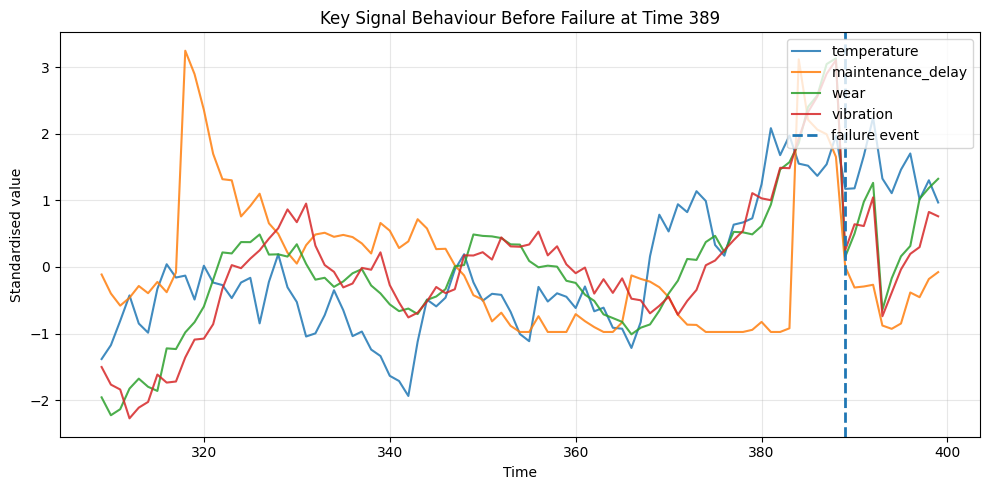


Compact graph recovery summary
----------------------------------
Recovered true links: 6
Estimated links: 10
True links: 16
Precision: 0.6
Recall: 0.375

Final summary table
-------------------
                  metric  value
          failure_events 45.000
            failure_rate  0.030
            test_roc_auc  0.804
estimated_link_precision  0.600
   estimated_link_recall  0.375


In [1]:
# ============================================================
# Exploratory Study on Lagged Causal Signals
# for Industrial Failure Root-Cause Analysis
# ============================================================

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

from statsmodels.tsa.stattools import grangercausalitytests

warnings.filterwarnings("ignore")

# Make printed tables compact and GitHub-friendly
pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

SEED = 42
np.random.seed(SEED)

N = 1500
MAX_LAG = 5

sensor_cols = [
    "load",
    "speed",
    "pressure",
    "temperature",
    "maintenance_delay",
    "wear",
    "vibration",
]

key_signal_cols = [
    "temperature",
    "maintenance_delay",
    "wear",
    "vibration",
]

analysis_cols = sensor_cols + ["failure"]


# ============================================================
# 1. Utility functions
# ============================================================


def print_table(title, obj, index=False, max_rows=None):
    """Print pandas objects without IPython display/HTML output."""
    print("\n" + title)
    print("-" * len(title))

    if isinstance(obj, pd.Series):
        obj = obj.to_frame()

    if isinstance(obj, pd.DataFrame):
        if max_rows is not None:
            obj = obj.head(max_rows)
        print(obj.to_string(index=index))
    else:
        print(obj)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def standardize(x):
    x = np.asarray(x)
    return (x - np.mean(x)) / (np.std(x) + 1e-8)


def safe_corr(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    if np.std(x) < 1e-8 or np.std(y) < 1e-8:
        return 0.0

    return np.corrcoef(x, y)[0, 1]


# ============================================================
# 2. Synthetic data generation
# ============================================================


def generate_industrial_failure_data(n=1500, seed=42):
    """
    Synthetic industrial time-series data.

    The simulation includes:
    - multiple operating regimes;
    - noisy sensor measurements;
    - lagged dependencies;
    - maintenance delay events;
    - gradual component wear;
    - rare failure events;
    - partial reset after repair.

    Approximate dependency logic:
        operating_regime -> load / speed / pressure
        load, speed, pressure -> temperature
        temperature, maintenance_delay, load -> wear
        wear, pressure -> vibration
        pressure, temperature, maintenance_delay, wear, vibration -> failure
    """

    rng = np.random.default_rng(seed)

    regime = np.zeros(n, dtype=int)
    load = np.zeros(n)
    speed = np.zeros(n)
    pressure = np.zeros(n)
    temperature = np.zeros(n)
    maintenance_delay = np.zeros(n)
    wear = np.zeros(n)
    vibration = np.zeros(n)
    failure_risk = np.zeros(n)
    failure = np.zeros(n, dtype=int)

    transition_matrix = np.array([
        [0.94, 0.04, 0.02],
        [0.08, 0.88, 0.04],
        [0.12, 0.08, 0.80],
    ])

    regime[0] = 0

    for t in range(1, n):
        regime[t] = rng.choice([0, 1, 2], p=transition_matrix[regime[t - 1]])

        if regime[t] == 0:
            load_shift = 0.0
            speed_shift = 0.0
            pressure_shift = 0.0
            noise_scale = 0.6
        elif regime[t] == 1:
            load_shift = 1.2
            speed_shift = 0.4
            pressure_shift = 0.5
            noise_scale = 0.7
        else:
            load_shift = 0.7
            speed_shift = -0.3
            pressure_shift = 1.0
            noise_scale = 1.0

        missed_maintenance = rng.binomial(1, 0.035)

        maintenance_delay[t] = (
            0.90 * maintenance_delay[t - 1]
            + 1.6 * missed_maintenance
            + rng.normal(0, 0.10)
        )
        maintenance_delay[t] = max(0, maintenance_delay[t])

        load[t] = (
            0.72 * load[t - 1]
            + load_shift
            + rng.normal(0, noise_scale)
        )

        speed[t] = (
            0.62 * speed[t - 1]
            + speed_shift
            + rng.normal(0, noise_scale)
        )

        pressure[t] = (
            0.65 * pressure[t - 1]
            + 0.25 * load[t - 1]
            + pressure_shift
            + rng.normal(0, noise_scale)
        )

        temperature[t] = (
            0.58 * temperature[t - 1]
            + 0.38 * load[t - 1]
            + 0.28 * speed[t - 1]
            + 0.12 * pressure[t - 1]
            + rng.normal(0, 0.55)
        )

        wear[t] = (
            0.91 * wear[t - 1]
            + 0.22 * temperature[t - 1]
            + 0.32 * maintenance_delay[t - 1]
            + 0.08 * max(load[t - 1], 0)
            + rng.normal(0, 0.35)
        )
        wear[t] = max(0, wear[t])

        vibration[t] = (
            0.64 * vibration[t - 1]
            + 0.50 * wear[t - 1]
            + 0.10 * pressure[t - 1]
            + rng.normal(0, 0.50)
        )

        if t > 20:
            wear_z = standardize(wear[:t + 1])[-1]
            vib_z = standardize(vibration[:t + 1])[-1]
            pressure_z = standardize(pressure[:t + 1])[-1]
            temp_z = standardize(temperature[:t + 1])[-1]
            maint_z = standardize(maintenance_delay[:t + 1])[-1]
        else:
            wear_z = vib_z = pressure_z = temp_z = maint_z = 0

        raw_risk = (
            0.90 * wear_z
            + 0.70 * vib_z
            + 0.35 * pressure_z
            + 0.25 * temp_z
            + 0.30 * maint_z
            - 2.8
        )

        failure_risk[t] = sigmoid(raw_risk)

        if failure_risk[t] > 0.72 and rng.random() < failure_risk[t] * 0.22:
            failure[t] = 1

            # Partial repair/reset after failure
            wear[t] *= 0.45
            vibration[t] *= 0.50
            maintenance_delay[t] *= 0.40
            temperature[t] *= 0.70

    df = pd.DataFrame({
        "time": np.arange(n),
        "operating_regime": regime,
        "load": load,
        "speed": speed,
        "pressure": pressure,
        "temperature": temperature,
        "maintenance_delay": maintenance_delay,
        "wear": wear,
        "vibration": vibration,
        "failure_risk": failure_risk,
        "failure": failure,
    })

    regime_map = {
        0: "normal",
        1: "high_load",
        2: "unstable",
    }

    df["regime_label"] = df["operating_regime"].map(regime_map)

    return df


# ============================================================
# 3. Generate dataset and inspect it
# ============================================================


df = generate_industrial_failure_data(N, SEED)

print("Dataset shape:", df.shape)
print("Number of failure events:", int(df["failure"].sum()))
print("Failure rate:", round(df["failure"].mean(), 4))

regime_distribution = df["regime_label"].value_counts(normalize=True).round(3).to_frame("share")
print_table("Operating regime distribution", regime_distribution, index=True)
print_table("First rows of the simulated dataset", df.head(), index=False)

true_edges = [
    ("operating_regime", "load"),
    ("operating_regime", "speed"),
    ("operating_regime", "pressure"),
    ("load", "temperature"),
    ("speed", "temperature"),
    ("pressure", "temperature"),
    ("temperature", "wear"),
    ("maintenance_delay", "wear"),
    ("load", "wear"),
    ("wear", "vibration"),
    ("pressure", "vibration"),
    ("pressure", "failure"),
    ("temperature", "failure"),
    ("maintenance_delay", "failure"),
    ("wear", "failure"),
    ("vibration", "failure"),
]

print("\nSimplified true dependency structure used in the simulation")
print("-" * 61)
for src, dst in true_edges:
    print(f"{src} -> {dst}")


# ============================================================
# 4. Visualise key signals and operating regimes
# ============================================================


plt.figure(figsize=(10, 5))

for col in key_signal_cols:
    plt.plot(df["time"], standardize(df[col]), label=col, alpha=0.85)

failure_times = df.loc[df["failure"] == 1, "time"]

for ft in failure_times:
    plt.axvline(ft, linestyle="--", alpha=0.18)

plt.title("Key Degradation-Related Signals with Failure Events")
plt.xlabel("Time")
plt.ylabel("Standardised value")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

plt.figure(figsize=(10, 3))
plt.plot(df["time"], df["operating_regime"], drawstyle="steps-post")
plt.yticks([0, 1, 2], ["normal", "high_load", "unstable"])
plt.title("Operating Regimes Over Time")
plt.xlabel("Time")
plt.ylabel("Regime")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()


# ============================================================
# 5. Correlation-based baseline
# ============================================================


corr_with_failure = df[analysis_cols].corr()["failure"].drop("failure")
corr_ranking = corr_with_failure.abs().sort_values(ascending=False)

print_table(
    "Naive correlation-based ranking",
    corr_ranking.to_frame("absolute_correlation_with_failure"),
    index=True,
)

plt.figure(figsize=(8, 5))
corr_ranking.sort_values().plot(kind="barh")
plt.title("Naive Correlation-Based Ranking of Candidate Failure Signals")
plt.xlabel("Absolute correlation with failure")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()


# ============================================================
# 6. Lagged dependency scoring
# ============================================================


def lagged_dependency_score(df, source, target, max_lag=5):
    """
    Simple lag-aware dependency score.

    For each lag, compute correlation between source(t-lag) and target(t).
    The strongest absolute lagged correlation is used as the score.

    This is not proof of causality. It is an exploratory time-ordered signal.
    """

    scores = []

    for lag in range(1, max_lag + 1):
        source_lagged = df[source].shift(lag)
        target_current = df[target]

        valid = pd.concat([source_lagged, target_current], axis=1).dropna()

        corr = safe_corr(valid.iloc[:, 0], valid.iloc[:, 1])
        scores.append((lag, corr, abs(corr)))

    best_lag, best_corr, best_score = max(scores, key=lambda x: x[2])

    return {
        "source": source,
        "target": target,
        "best_lag": best_lag,
        "lagged_correlation": best_corr,
        "lagged_score": best_score,
    }


candidate_sources = sensor_cols + ["operating_regime"]
candidate_targets = sensor_cols + ["failure"]

lagged_results = []

for source in candidate_sources:
    for target in candidate_targets:
        if source != target:
            lagged_results.append(
                lagged_dependency_score(df, source, target, MAX_LAG)
            )

lagged_df = pd.DataFrame(lagged_results)
lagged_df_sorted = lagged_df.sort_values("lagged_score", ascending=False)

print_table("Top lag-aware dependency signals", lagged_df_sorted.head(10), index=False)


# ============================================================
# 7. Granger-style time-ordered analysis
# ============================================================


def granger_style_score(df, source, target, max_lag=5):
    """
    Granger-style test.

    Question:
    Do past values of source help predict current values of target,
    beyond past values of target?

    This is not equivalent to proving causality.
    """

    test_data = df[[target, source]].dropna()

    if test_data[target].nunique() < 2 or test_data[source].nunique() < 2:
        return {
            "source": source,
            "target": target,
            "best_lag": np.nan,
            "p_value": np.nan,
            "granger_score": 0.0,
        }

    try:
        result = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)

        p_values = []

        for lag in range(1, max_lag + 1):
            p_val = result[lag][0]["ssr_ftest"][1]
            p_values.append((lag, p_val))

        best_lag, best_p = min(p_values, key=lambda x: x[1])

        return {
            "source": source,
            "target": target,
            "best_lag": best_lag,
            "p_value": best_p,
            "granger_score": -np.log10(best_p + 1e-12),
        }

    except Exception:
        return {
            "source": source,
            "target": target,
            "best_lag": np.nan,
            "p_value": np.nan,
            "granger_score": 0.0,
        }


granger_results = []

for source in candidate_sources:
    for target in candidate_targets:
        if source != target:
            granger_results.append(
                granger_style_score(df, source, target, MAX_LAG)
            )

granger_df = pd.DataFrame(granger_results)
granger_df_sorted = granger_df.sort_values("granger_score", ascending=False)

print_table("Top Granger-style time-ordered signals", granger_df_sorted.head(10), index=False)


# ============================================================
# 8. Combined dependency ranking and root-cause signal ranking
# ============================================================


combined = lagged_df.merge(
    granger_df,
    on=["source", "target"],
    suffixes=("_lagged", "_granger"),
)

max_granger = combined["granger_score"].max() + 1e-8
combined["normalised_granger_score"] = combined["granger_score"] / max_granger

combined["combined_signal_score"] = (
    0.55 * combined["lagged_score"]
    + 0.45 * combined["normalised_granger_score"]
)

estimated_edges = combined.sort_values(
    "combined_signal_score",
    ascending=False,
).head(10)

estimated_edges_table = estimated_edges[[
    "source",
    "target",
    "best_lag_lagged",
    "lagged_correlation",
    "lagged_score",
    "p_value",
    "granger_score",
    "combined_signal_score",
]]

print_table("Top estimated time-ordered dependency links", estimated_edges_table, index=False)

failure_links = combined[combined["target"] == "failure"].copy()

failure_links["root_cause_signal_score"] = (
    0.50 * failure_links["lagged_score"]
    + 0.50 * failure_links["normalised_granger_score"]
)

root_cause_ranking = failure_links.sort_values(
    "root_cause_signal_score",
    ascending=False,
)

root_cause_table = root_cause_ranking[[
    "source",
    "best_lag_lagged",
    "lagged_correlation",
    "lagged_score",
    "p_value",
    "granger_score",
    "root_cause_signal_score",
]]

print_table("Exploratory root-cause signal ranking for failure", root_cause_table, index=False)

plt.figure(figsize=(8, 5))
root_cause_ranking.set_index("source")["root_cause_signal_score"].sort_values().plot(kind="barh")
plt.title("Exploratory Root-Cause Signal Ranking for Failure")
plt.xlabel("Root-cause signal score")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()


# ============================================================
# 9. Predictive validation with lagged logistic regression
# ============================================================


def create_lagged_features(df, columns, lags):
    X = pd.DataFrame(index=df.index)

    for col in columns:
        for lag in lags:
            X[f"{col}_lag{lag}"] = df[col].shift(lag)

    return X


feature_cols = sensor_cols + ["operating_regime"]

X = create_lagged_features(df, feature_cols, lags=[1, 2, 3, 4, 5])
y = df["failure"]

model_data = pd.concat([X, y], axis=1).dropna()

X_model = model_data.drop(columns=["failure"])
y_model = model_data["failure"]

split_idx = int(len(model_data) * 0.7)

X_train = X_model.iloc[:split_idx]
X_test = X_model.iloc[split_idx:]

y_train = y_model.iloc[:split_idx]
y_test = y_model.iloc[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED,
)

clf.fit(X_train_scaled, y_train)

pred_proba = clf.predict_proba(X_test_scaled)[:, 1]
pred_label = (pred_proba > 0.5).astype(int)

auc = roc_auc_score(y_test, pred_proba)

print("\nPredictive baseline: logistic regression with lagged features")
print("-" * 62)
print("Time-based train/test split: 70% train, 30% test")
print("Test ROC AUC:", round(auc, 3))
print("\nClassification report:")
print(classification_report(y_test, pred_label))

coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": clf.coef_[0],
})

coef_df["absolute_coefficient"] = coef_df["coefficient"].abs()
coef_df_sorted = coef_df.sort_values("absolute_coefficient", ascending=False)

print_table("Top predictive lagged features", coef_df_sorted.head(10), index=False)

plt.figure(figsize=(9, 5))
coef_df_sorted.head(10).sort_values("absolute_coefficient").set_index("feature")["absolute_coefficient"].plot(kind="barh")
plt.title("Top Predictive Lagged Features")
plt.xlabel("Absolute logistic regression coefficient")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()


# ============================================================
# 10. Local pre-failure case study
# ============================================================


def explain_failure_event(df, failure_time, variables, window=25):
    """
    Simple local pre-failure explanation.

    Compares the average value of each variable shortly before failure
    with its earlier baseline window.
    """

    pre_start = max(0, failure_time - 2 * window)
    pre_end = max(0, failure_time - window)
    local_start = max(0, failure_time - window)
    local_end = failure_time

    baseline = df.loc[pre_start:pre_end, variables]
    local = df.loc[local_start:local_end, variables]

    rows = []

    for col in variables:
        baseline_mean = baseline[col].mean()
        local_mean = local[col].mean()
        change = local_mean - baseline_mean

        rows.append({
            "variable": col,
            "baseline_mean": baseline_mean,
            "pre_failure_mean": local_mean,
            "change": change,
            "absolute_change": abs(change),
        })

    return pd.DataFrame(rows).sort_values("absolute_change", ascending=False)


failure_times = df.loc[df["failure"] == 1, "time"]
late_failure_times = failure_times[failure_times > 300]

if len(late_failure_times) > 0:
    selected_failure_time = int(late_failure_times.iloc[0])
elif len(failure_times) > 0:
    selected_failure_time = int(failure_times.iloc[-1])
else:
    selected_failure_time = None


if selected_failure_time is not None:
    print(f"\nLocal pre-failure explanation for failure at time {selected_failure_time}")
    print("-" * 72)

    local_explanation = explain_failure_event(
        df,
        selected_failure_time,
        key_signal_cols,
        window=25,
    )

    print_table("Local pre-failure changes", local_explanation, index=False)

    local_window = df.loc[
        max(0, selected_failure_time - 80):selected_failure_time + 10,
        ["time"] + key_signal_cols + ["failure"],
    ]

    plt.figure(figsize=(10, 5))

    for col in key_signal_cols:
        plt.plot(
            local_window["time"],
            standardize(local_window[col]),
            label=col,
            alpha=0.85,
        )

    plt.axvline(
        selected_failure_time,
        linestyle="--",
        linewidth=2,
        label="failure event",
    )

    plt.title(f"Key Signal Behaviour Before Failure at Time {selected_failure_time}")
    plt.xlabel("Time")
    plt.ylabel("Standardised value")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close()

else:
    print("No failure events were generated. Try increasing N.")


# ============================================================
# 11. Compact graph recovery summary
# ============================================================


true_edges_set = set(true_edges)

estimated_edge_pairs = set(
    zip(estimated_edges["source"], estimated_edges["target"])
)

matched_edges = true_edges_set.intersection(estimated_edge_pairs)

precision = len(matched_edges) / max(len(estimated_edge_pairs), 1)
recall = len(matched_edges) / max(len(true_edges_set), 1)

print("\nCompact graph recovery summary")
print("-" * 34)
print("Recovered true links:", len(matched_edges))
print("Estimated links:", len(estimated_edge_pairs))
print("True links:", len(true_edges_set))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))

summary_table = pd.DataFrame({
    "metric": [
        "failure_events",
        "failure_rate",
        "test_roc_auc",
        "estimated_link_precision",
        "estimated_link_recall",
    ],
    "value": [
        int(df["failure"].sum()),
        round(df["failure"].mean(), 4),
        round(auc, 3),
        round(precision, 3),
        round(recall, 3),
    ],
})

print_table("Final summary table", summary_table, index=False)
